In [2]:
#IMPORTING LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from collections import Counter

import nltk

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

import warnings

warnings.filterwarnings('ignore')

In [7]:
#LOADING DATSETS
apps = pd.read_csv(
r"C:\Users\ACER\Downloads\apps.csv\apps.csv"
)

reviews = pd.read_csv(
r"C:\Users\ACER\Downloads\user_reviews.csv\user_reviews.csv"
)

In [8]:
apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [9]:
#UNDERSTANDING DATASET

In [10]:
apps.shape

reviews.shape

(64295, 5)

In [11]:
apps.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='str')

In [12]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   str    
 6   Installs        9659 non-null   str    
 7   Type            9658 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(1), int64(2), str(11)
memory usage: 1.0 MB


In [13]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [14]:
#MERGING DATASET

In [15]:
df = pd.merge(

reviews,

apps,

on='App',

how='inner'

)

In [16]:
df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Unnamed: 0,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,1393,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,1393,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2,10 Best Foods for You,NaN,NaN,NaN,NaN,1393,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,1393,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,1393,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up


In [17]:
df.shape

(61556, 18)

In [18]:
#DATA CLEANING

In [19]:
df.isnull().sum()

App                           0
Translated_Review         25627
Sentiment                 25622
Sentiment_Polarity        25622
Sentiment_Subjectivity    25622
Unnamed: 0                    0
Category                      0
Rating                        0
Reviews                       0
Size                      20406
Installs                      0
Type                          0
Price                         0
Content Rating                0
Genres                        0
Last Updated                  0
Current Ver                   0
Android Ver                   0
dtype: int64

In [20]:
df = df.dropna()

In [21]:
df = df.drop_duplicates()

In [22]:
df = df.reset_index(drop=True)

In [23]:
#TEXT PROSSESING

In [24]:
stop_words = set(
stopwords.words('english')
)

lemmatizer = WordNetLemmatizer()

In [25]:
def clean_review(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    words = text.split()

    words = [

        lemmatizer.lemmatize(word)

        for word in words

        if word not in stop_words

    ]

    return " ".join(words)

In [26]:
df['processed_review'] = (

df['Translated_Review']

.apply(clean_review)

)

In [27]:
#FEATURE ENGINEERING

In [28]:
df['review_length'] = (

df['processed_review']

.apply(len)

)

df['word_count'] = (

df['processed_review']

.apply(

lambda x: len(x.split())

)

)

In [29]:
#CREATE CUSTOMER SATISFACTION SCORE

In [30]:
score_map = {

'Positive':1,

'Neutral':0,

'Negative':-1

}

df['satisfaction_score'] = (

df['Sentiment']

.map(score_map)

)

In [31]:
#EDA

In [32]:
#GRAPH 1

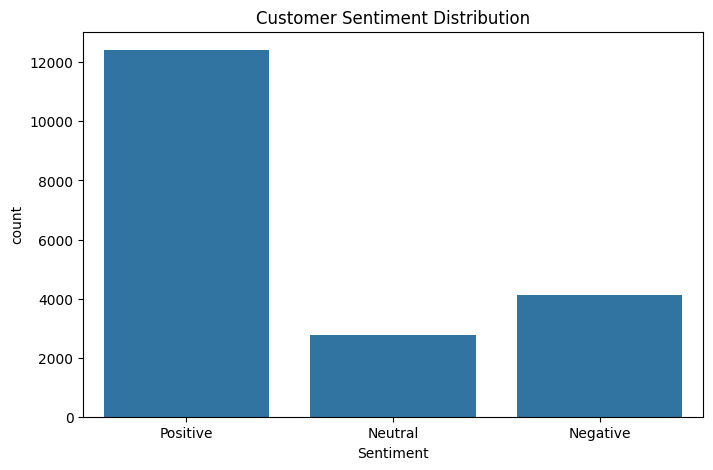

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(

x='Sentiment',

data=df

)

plt.title(

'Customer Sentiment Distribution'

)

plt.show()

In [34]:
#GRAPH 2

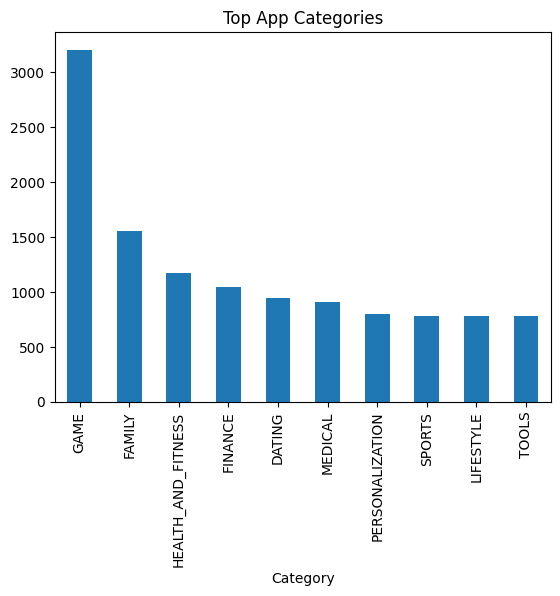

In [35]:
top_categories = (

df['Category']

.value_counts()

.head(10)

)

top_categories.plot(

kind='bar'

)

plt.title(

'Top App Categories'

)

plt.show()

In [36]:
#GRAPH 3

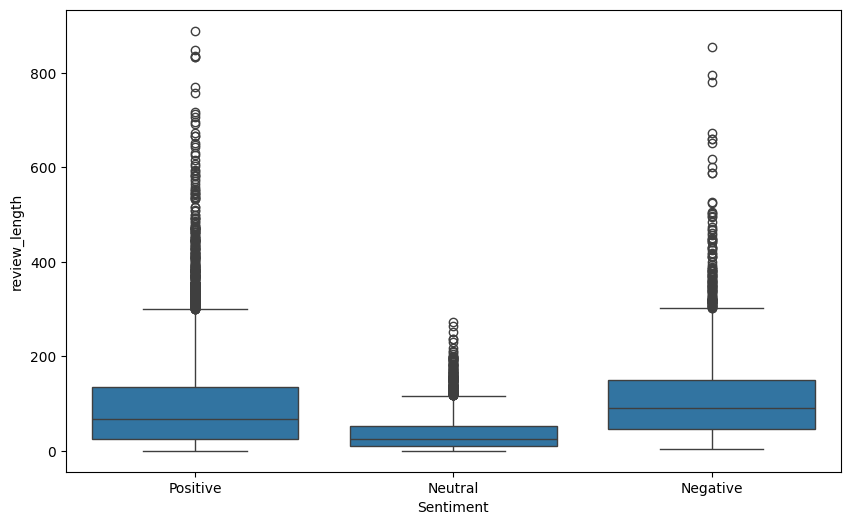

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(

x='Sentiment',

y='review_length',

data=df

)

plt.show()

In [38]:
#GRAPH 4

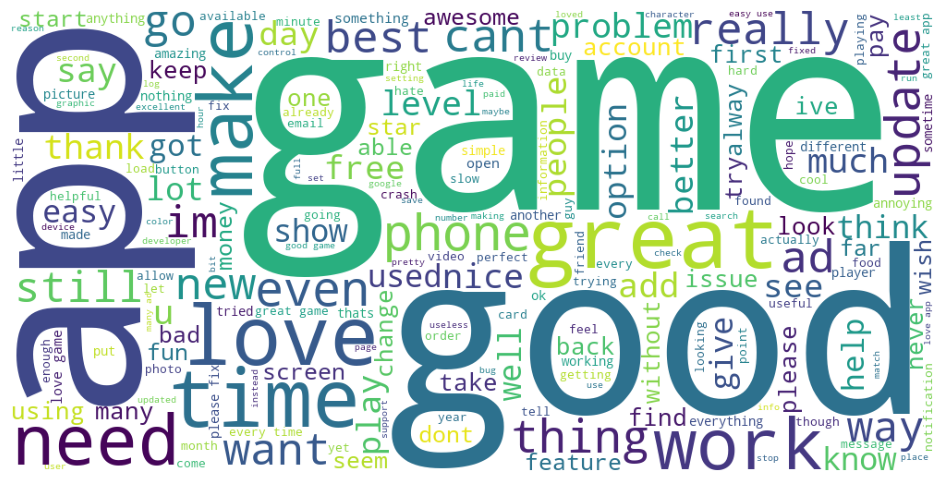

In [39]:
text = " ".join(

df['processed_review']

)

wordcloud = WordCloud(

width=1000,

height=500,

background_color='white'

).generate(text)

plt.figure(

figsize=(12,6)

)

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [40]:
#TF-IDF

In [41]:
vectorizer = TfidfVectorizer(

max_features=5000

)

X = vectorizer.fit_transform(

df['processed_review']

)

y = df['Sentiment']

In [42]:
#TRAIN-TEST SPLIT

In [43]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

In [44]:
#MODEL BUILDING

In [46]:
model = LogisticRegression()

model.fit(

X_train,

y_train

)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [47]:
#PREDICTION

In [48]:
y_pred = model.predict(

X_test

)

In [49]:
#EVALUATION

In [50]:
accuracy_score(

y_test,

y_pred

)

0.8729296066252588

In [51]:
#CLASSIFICATION REPORT

In [52]:
print(

classification_report(

y_test,

y_pred

)

)

              precision    recall  f1-score   support

    Negative       0.87      0.70      0.78       866
     Neutral       0.81      0.77      0.79       542
    Positive       0.88      0.96      0.92      2456

    accuracy                           0.87      3864
   macro avg       0.86      0.81      0.83      3864
weighted avg       0.87      0.87      0.87      3864



In [53]:
#CONFUSION MATRIX

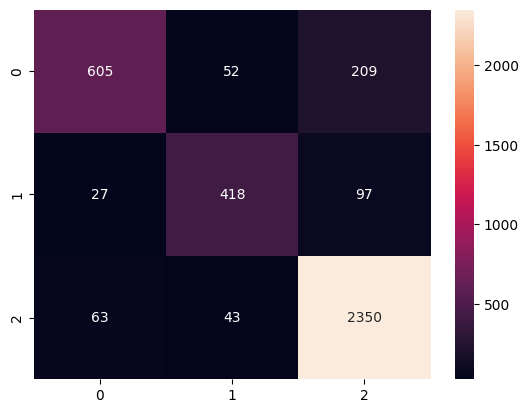

In [54]:
cm = confusion_matrix(

y_test,

y_pred

)

sns.heatmap(

cm,

annot=True,

fmt='d'

)

plt.show()